# Итоговая работа. Signal types classification

### Цель задачи

В работе решается задача автоматической кластеризации сигналов сцинтилляционного детектора из соревнования [Signal types classification](https://www.kaggle.com/competitions/signal-types-classification). Нужно разделить **23 479** сигналов на три группы без открытой разметки:

- `0` - первый основной тип сигнала
- `1` - второй основной тип сигнала
- `2` - неоднозначные, смешанные или аномальные сигналы

Метрика - **accuracy**

### Описание данных

Согласно `Description`, данные получены со сцинтилляционного детектора на основе органических кристаллов паратерфенила. При прохождении частицы через сцинтиллятор возникает короткая вспышка света, а зарегистрированный импульс несет информацию о типе события. Для разделения сигналов важны:

- Высота импульса (`amplitude`)
- Площадь под импульсом (`integral`, `area`)
- Форма хвоста после максимума (`PSD`, `decay_time`)
- Область неоднозначных событий около границы между основными типами

После удаления служебных колонок каждый объект описывается 500 временными отсчетами:

$$
X \in \mathbb{R}^{23479 \times 500}
$$

## 1. Загрузка данных с Яндекс Диска

Датасет загружается по публичной ссылке Яндекс Диска. После чтения добавляется колонка `Index`, чтобы явно сохранить исходный порядок объектов для файла ответа. 
- Также, отдельно ограничиваем фоновые потоки численных библиотек для стабильного запуска ноутбука.

In [3]:
# Импортируем библиотеки и фиксируем окружение.
import os
import sys
import warnings
from itertools import permutations
from pathlib import Path
for var in ("LOKY_MAX_CPU_COUNT", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(var, "1")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from scipy.signal import find_peaks
from scipy.stats import kurtosis, skew
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
EPS = 1e-9
N_SIGNALS, N_SAMPLES = 23_479, 500
MODEL_SAMPLE_SIZE = 4_000
KAGGLE_SCORE = 0.73005
DATA_FILE_NAME = "Run200_Wave_0_1.txt"
YANDEX_DISK_URL = "https://disk.yandex.ru/d/GlfcEvVNv1xsbQ"
OUTPUT_DIR = Path("kaggle_final_submissions")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
def load_dataset_from_yadisk(public_key: str) -> pd.DataFrame:
    base_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download"
    resp = requests.get(base_url, params={"public_key": public_key})
    resp.raise_for_status()
    return pd.read_csv(
        resp.json()["href"],
        sep=" ",
        header=None,
        skipinitialspace=True,
        low_memory=False,
    )
# Читаем данные и сохраняем исходный порядок объектов.
data = load_dataset_from_yadisk(YANDEX_DISK_URL)
data_raw = data.dropna(axis=1, how="all").copy()
data_raw["Index"] = np.arange(len(data_raw))
display(data_raw.head())

# Отделяем metadata от 500 отсчетов сигнала.
metadata = data_raw.iloc[:, :4].copy()
raw_values = data_raw.iloc[:, 4:4 + N_SAMPLES].to_numpy(dtype=np.float32)
raw_nan_count = int(np.isnan(raw_values).sum())

assert raw_values.shape == (N_SIGNALS, N_SAMPLES), raw_values.shape
assert np.isfinite(raw_values).all()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,Index
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,...,14820,14819,14821,14827,14823,14817,14825,14824,14824,14815,14816,14817,14825,14817,14818,14823,14821,14824,14821,14824,14815,14817,14823,14820,14816,14818,14824,14815,14820,14818,14818,14818,14816,14824,14822,14823,14816,14818,14823,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819,0
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,14823,14823,14822,14824,14827,14824,14822,14823,14823,14824,14824,14820,14824,14823,14822,14818,14828,14819,14824,14823,14820,14821,14822,14817,14824,14821,14823,14822,14819,14825,14824,14822,14827,14820,14820,14828,...,14822,14820,14822,14819,14822,14820,14822,14820,14817,14818,14820,14824,14816,14819,14828,14820,14821,14824,14817,14818,14819,14820,14820,14822,14826,14824,14815,14819,14820,14820,14821,14819,14825,14822,14819,14824,14827,14817,14824,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820,1
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,14823,14823,14823,14824,14819,14820,14823,14821,14820,14822,14818,14819,14820,14824,14822,14822,14820,14820,14824,14822,14820,14822,14823,14823,14822,14815,14820,14824,14827,14827,14823,14824,14820,14825,14820,14825,...,14822,14820,14820,14818,14818,14817,14814,14823,14818,14819,14818,14824,14821,14820,14819,14824,14825,14818,14820,14820,14816,14815,14821,14820,14827,14819,14819,14824,14821,14819,14822,14822,14820,14820,14822,14822,14826,14823,14822,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821,2
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,14820,14824,14826,14821,14818,14826,14820,14824,14824,14822,14823,14820,14819,14820,14820,14823,14820,14824,14823,14820,14823,14825,14827,14822,14818,14828,14824,14828,14820,14822,14824,14822,14828,14824,14820,14822,...,14829,14823,14824,14820,14823,14819,14821,14823,14822,14822,14820,14817,14827,14819,14826,14824,14823,14823,14822,14824,14823,14823,14823,14820,14821,14823,14822,14824,14822,14820,14820,14820,14825,14820,14822,14823,14821,14824,14824,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822,3
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,14822,14825,14822,14823,14820,14823,14823,14821,14820,14826,14820,14818,14819,14821,14822,14825,14820,14823,14823,14817,14823,14827,14823,14820,14817,14823,14828,14818,14823,14825,14820,14817,14819,14823,14824,14820,...,14823,14823,14824,14819,14819,14820,14820,14819,14819,14820,14816,14819,14824,14819,14819,14820,14820,14823,14819,14820,14822,14823,14822,14817,14821,14820,14821,14817,14824,14820,14817,14820,14817,14823,14823,14820,14823,14820,14819,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825,4


После удаления пустой trailing-колонки и добавления `Index` таблица имеет **23 479 строк и 505 столбцов**. Пропусков в матрице сигналов нет. 

- 4 колонки - metadata
- 500 колонок - отсчеты сигнала
- `Index` хранит исходный порядок

## 2. Предобработка сигналов

В теор. материалах отдельно подчеркивается важность формы импульса: амплитуды, площади и хвоста после максимума. Поэтому сначала нужно оценить базовую линию сигнала.

- Baseline считаем по первым 50 отсчетам:

$$
baseline_i = \frac{1}{50}\sum_{t=0}^{49}x_{i,t}
$$

Затем разворачиваем импульс вверх:

$$
s_{i,t} = baseline_i - x_{i,t}
$$

В результате нашего преобразования максимум будет соответствать амплитуде, сумма положительной части - площади импульса, а участок после пика - хвосту высвечивания.

In [7]:
def preprocess_signals(values: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    baseline = values[:, :50].mean(axis=1)
    noise_std = values[:, :50].std(axis=1)
    return baseline[:, None] - values, baseline, noise_std


signal_up, baseline, noise_std = preprocess_signals(raw_values)
positive_signal = np.clip(signal_up, 0, None)
positive_amplitude = positive_signal.max(axis=1)

# Сводим числовую проверку предобработки.
preprocessing_stats = pd.DataFrame({
    "metric": ["baseline", "noise_std", "positive_amplitude"],
    "mean": [baseline.mean(), noise_std.mean(), positive_amplitude.mean()],
    "median": [np.median(baseline), np.median(noise_std), np.median(positive_amplitude)],
    "min": [baseline.min(), noise_std.min(), positive_amplitude.min()],
    "max": [baseline.max(), noise_std.max(), positive_amplitude.max()],
})
display(preprocessing_stats)

,metric,mean,median,min,max
0,baseline,14822.9658,14822.9600,14818.9199,14826.4805
1,noise_std,2.6807,2.6746,1.6734,3.7537
2,positive_amplitude,1835.1047,812.5400,104.2998,14824.8398


По результатам видим, что Baseline оказался стабильным: 
- Медиана **14822.96**
- Шум также узкий (median `noise_std = 2.67`)

Можем сделать вывод о том, что начальные 50 отсчетов подходят для оценки нулевой линии, можем переходить к EDA.

## 3. Первичный анализ сигналов (EDA)

Проведем анализ шумов (по начальному участку):

$$
noise_i = std(x_{i,0:50})
$$

Нас интересует результат, когда пики расположены примерно в одной временной области, но различаются амплитуды и хвосты. В таком случае оправдано строить признаки PSD, decay-time и признаки площади, как и предлагается в методических материалах.

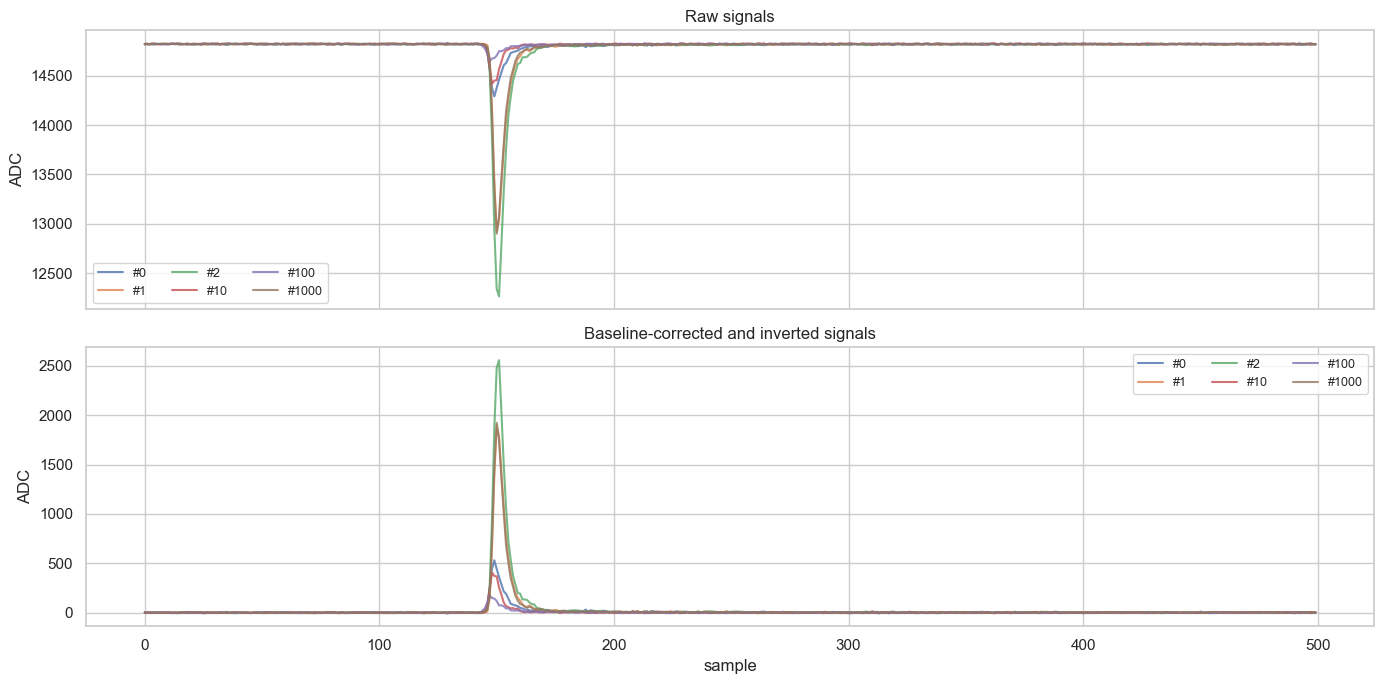

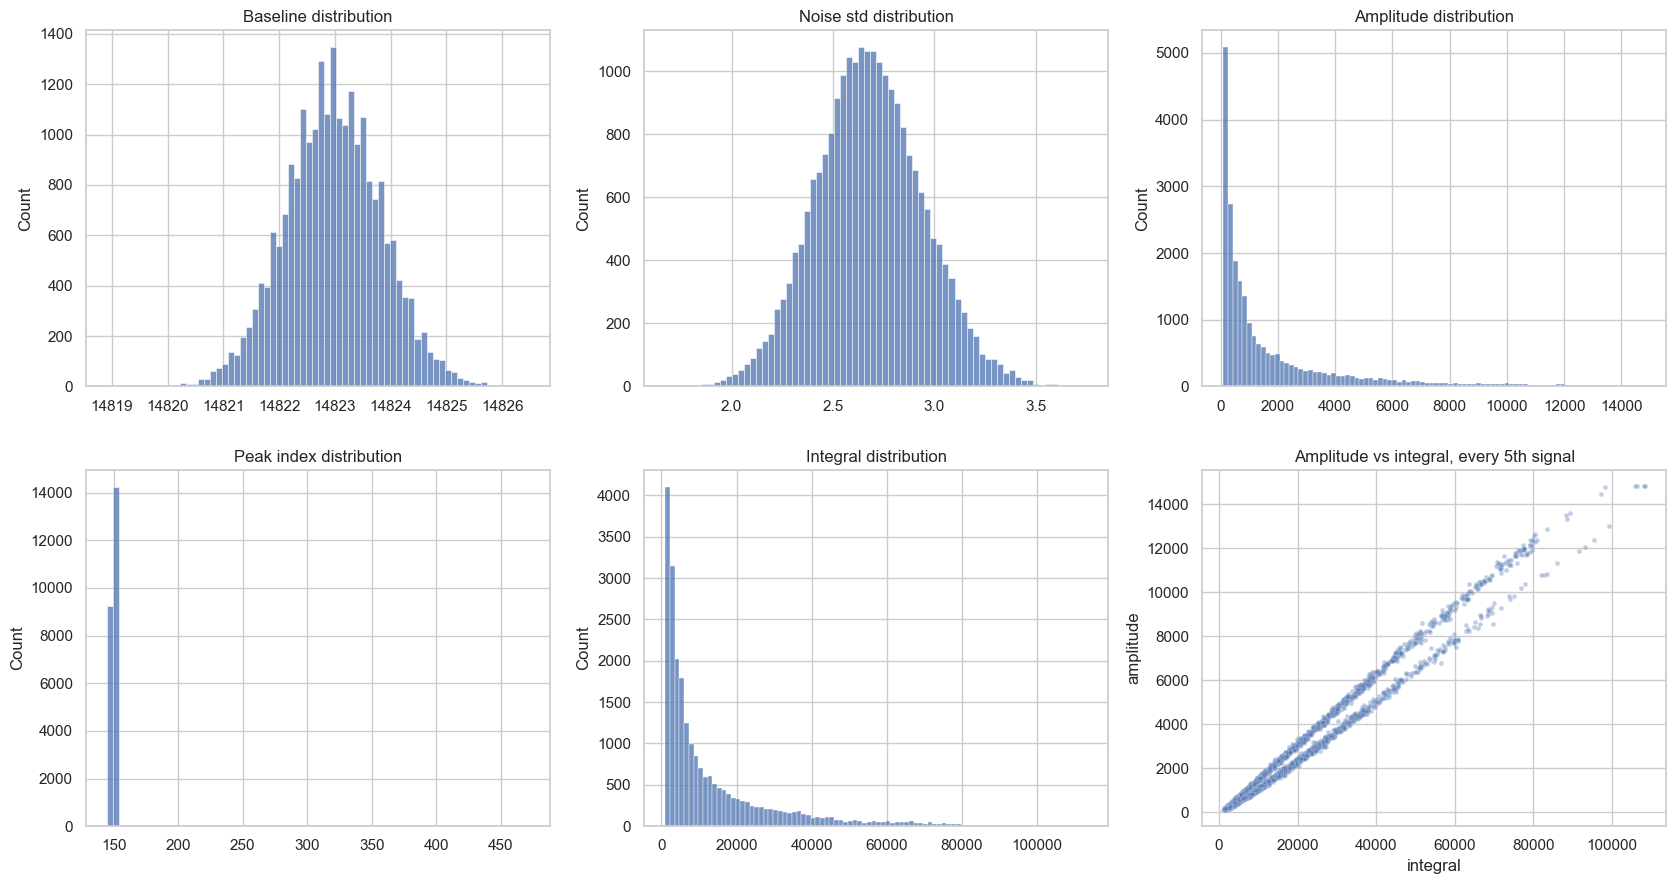

In [10]:
# Считаем базовые EDA-характеристики.
peak_idx_pre = positive_signal.argmax(axis=1)
amplitude_pre = positive_signal.max(axis=1)
integral_pre = positive_signal.sum(axis=1)

# Показываем примеры сырых и инвертированных сигналов.
sample_ids = [0, 1, 2, 10, 100, 1000]
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for idx in sample_ids:
    axes[0].plot(raw_values[idx], alpha=0.8, label=f"#{idx}")
    axes[1].plot(signal_up[idx], alpha=0.8, label=f"#{idx}")
for ax, title in zip(axes, ["Raw signals", "Baseline-corrected and inverted signals"]):
    ax.set_title(title)
    ax.set_ylabel("ADC")
    ax.legend(ncol=3, fontsize=9)
axes[1].set_xlabel("sample")
plt.tight_layout()
plt.show()

# Строим распределения и связь амплитуды с интегралом.
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
hist_data = [
    (baseline, "Baseline distribution"),
    (noise_std, "Noise std distribution"),
    (amplitude_pre, "Amplitude distribution"),
    (peak_idx_pre, "Peak index distribution"),
    (integral_pre, "Integral distribution"),
]
for ax, (values, title) in zip(axes.ravel()[:5], hist_data):
    sns.histplot(values, bins=90 if "Amplitude" in title or "Integral" in title else 70, ax=ax)
    ax.set_title(title)
sns.scatterplot(x=integral_pre[::5], y=amplitude_pre[::5], s=12, alpha=0.35, ax=axes.ravel()[5])
axes.ravel()[5].set(title="Amplitude vs integral, every 5th signal", xlabel="integral", ylabel="amplitude")
plt.tight_layout()
plt.show()

# Фиксируем числовые выводы по EDA.
amp_q = np.quantile(amplitude_pre, [0.05, 0.25, 0.5, 0.75, 0.95])
peak_low, peak_high = np.quantile(peak_idx_pre, [0.05, 0.95])
nonstandard_peak_share = np.mean((peak_idx_pre < peak_low) | (peak_idx_pre > peak_high))

- По графикам видно, что отрицательные импульсы становятся положительными пиками. Пики почти всегда около 150-го отсчета (median peak_idx = 150), значит временное выравнивание хорошее.

- Амплитуда и интеграл имеют длинный правый хвост. На графике amplitude-integral видны две почти линейные ветви, поэтому эта плоскость подходит для PCA-разделения. 

## 4. Feature Engineering

Построим физически интерпретируемые признаки, основанные на логике **pulse shape analysis / pulse shape discrimination**. Такие признаки компактнее и устойчивее сырых 500 отсчетов.

$$
amplitude_i = \max_t s_{i,t}
$$

$$
integral_i = \sum_t \max(s_{i,t}, 0)
$$

$$
tail\_integral_i = \sum_{t \ge t_{peak} + offset}\max(s_{i,t}, 0)
$$

$$
PSD_i = \frac{long_i - short_i}{long_i}
$$

$$
energy_i = \sum_t s_{i,t}^2
$$

* **`amplitude`** - высота импульса.
* **`integral`** - площадь под положительной частью сигнала.
* **`tail_integral`** и **`PSD`** - описывают поздний хвост и форму затухания.
* **`energy`** - суммарная энергетическая характеристика сигнала.

In [13]:
# Ищем первый отсчет после пика ниже заданного уровня.
def first_after_peak(signal: np.ndarray, peak: int, level: float, amp: float) -> int:
    candidates = np.flatnonzero(signal[peak:] <= level * amp)
    return int(peak + candidates[0]) if candidates.size else int(peak)


# Строим физически интерпретируемые признаки сигнала.
def extract_features(values: np.ndarray) -> pd.DataFrame:
    signal, baseline_local, noise_local = preprocess_signals(values)
    rows = []

    for i, row in enumerate(signal):
        positive = np.clip(row, 0, None)
        amp = float(positive.max())
        peak = int(positive.argmax())

        start_60 = first_after_peak(positive, peak, 0.60, amp)
        start_40 = first_after_peak(positive, peak, 0.40, amp)
        start_fixed_5 = min(peak + 5, positive.size - 1)
        start_fixed_10 = min(peak + 10, positive.size - 1)

        # Определяем конец импульса по уровню шума.
        threshold = 3.0 * float(noise_local[i])
        end_candidates = np.flatnonzero(positive[peak:] <= threshold)
        end = int(peak + end_candidates[0]) if end_candidates.size else positive.size
        end = min(max(end, peak + 20), positive.size)

        # Локальные функции для площадей, PSD и формы хвоста.
        def area(x: np.ndarray) -> float:
            return float(np.clip(x, 0, None).sum())

        def psd_from(start: int, short_len: int) -> float:
            long_area = area(positive[start:end])
            short_area = area(positive[start:min(start + short_len, end)])
            return (long_area - short_area) / long_area if long_area > EPS else 0.0

        def decay_length(start: int, level: float = 0.1) -> int:
            candidates = np.flatnonzero(positive[start:end] <= level * amp)
            return int(candidates[0]) if candidates.size else int(end - start)

        def rise_time(level_low: float = 0.1, level_high: float = 0.9) -> int:
            before_peak = positive[:peak + 1]
            low = np.flatnonzero(before_peak >= level_low * amp)
            high = np.flatnonzero(before_peak >= level_high * amp)
            return int(max(high[0] - low[0], 0)) if low.size and high.size else 0

        def fwhm() -> int:
            above_half = np.flatnonzero(positive >= 0.5 * amp)
            return int(above_half[-1] - above_half[0] + 1) if above_half.size else 0

        def log_tau(start: int) -> float:
            tail = positive[start:end]
            tail = tail[tail > max(threshold, EPS)]
            if len(tail) < 5:
                return 0.0
            slope, _ = np.polyfit(np.arange(len(tail), dtype=float), np.log(tail + EPS), 1)
            return float(-1.0 / slope) if slope < -EPS else 0.0

        # Добавляем peak-count и простые FFT-признаки.
        peaks, _ = find_peaks(positive, height=max(0.2 * amp, threshold), distance=15)
        fft_values = np.abs(np.fft.rfft(positive))
        fft_total = float(fft_values.sum() + EPS)
        fft_freq = np.fft.rfftfreq(positive.size)

        rows.append({
            "baseline": float(baseline_local[i]),
            "noise_std": float(noise_local[i]),
            "amplitude": amp,
            "integral": area(positive),
            "area_full": area(positive),
            "area_peak_to_end": area(positive[peak:end]),
            "area_60_to_end": area(positive[start_60:end]),
            "area_40_to_end": area(positive[start_40:end]),
            "tail_integral": area(positive[start_fixed_10:end]),
            "area_fixed5_to_end": area(positive[start_fixed_5:end]),
            "area_fixed10_to_end": area(positive[start_fixed_10:end]),
            "peak_idx": peak,
            "end_idx": end,
            "signal_len": end - peak,
            "rise_time": rise_time(),
            "fwhm": fwhm(),
            "snr": amp / (float(noise_local[i]) + EPS),
            "psd": psd_from(start_60, 20),
            "psd_60_short10": psd_from(start_60, 10),
            "psd_60_short20": psd_from(start_60, 20),
            "psd_60_short30": psd_from(start_60, 30),
            "psd_40_short20": psd_from(start_40, 20),
            "psd_fixed5_short20": psd_from(start_fixed_5, 20),
            "psd_fixed10_short20": psd_from(start_fixed_10, 20),
            "decay_time": decay_length(start_60),
            "decay_60": decay_length(start_60),
            "decay_40": decay_length(start_40),
            "tau_60": log_tau(start_60),
            "tau_40": log_tau(start_40),
            "energy": float(np.square(positive).sum()),
            "skew": float(skew(positive)),
            "kurtosis": float(kurtosis(positive)),
            "n_peaks": int(len(peaks)),
            "fft_total": fft_total,
            "fft_centroid": float((fft_freq * fft_values).sum() / fft_total),
            "fft_low_ratio": float(fft_values[1:10].sum() / fft_total),
            "fft_high_ratio": float(fft_values[30:].sum() / fft_total),
        })

    features = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    log_cols = [
        "amplitude", "integral", "area_full", "area_peak_to_end", "area_60_to_end",
        "area_40_to_end", "tail_integral", "noise_std", "snr", "energy",
    ]
    for col in log_cols:
        features[f"log_{col}"] = np.log1p(np.clip(features[col], 0, None))
    return features


# Рассчитываем признаки и проверяем численную корректность.
features = extract_features(raw_values)
nan_count = int(features.isna().sum().sum())
inf_count = int(np.isinf(features.to_numpy()).sum())
assert features.shape[0] == N_SIGNALS and nan_count == 0 and inf_count == 0

feature_quantiles = features[["amplitude", "integral", "psd", "decay_time", "energy"]].quantile([0.05, 0.5, 0.95]).T
psd_corr = features.corr(numeric_only=True)["psd"].drop("psd").abs().sort_values(ascending=False).head(5)

display(features.head())
display(feature_quantiles)
display(psd_corr.rename("abs_corr_with_psd").to_frame())

,baseline,noise_std,amplitude,integral,area_full,area_peak_to_end,area_60_to_end,area_40_to_end,tail_integral,area_fixed5_to_end,area_fixed10_to_end,peak_idx,end_idx,signal_len,rise_time,fwhm,snr,psd,psd_60_short10,psd_60_short20,psd_60_short30,psd_40_short20,psd_fixed5_short20,psd_fixed10_short20,decay_time,decay_60,decay_40,tau_60,tau_40,energy,skew,kurtosis,n_peaks,fft_total,fft_centroid,fft_low_ratio,fft_high_ratio,log_amplitude,log_integral,log_area_full,log_area_peak_to_end,log_area_60_to_end,log_area_40_to_end,log_tail_integral,log_noise_std,log_snr,log_energy
0,14821.4805,2.9068,530.4805,5108.0469,5108.0469,2849.5312,1514.0898,1010.1289,434.7266,1010.1289,434.7266,149,173,24,3,5,182.4952,0.0181,0.1831,0.0181,0.0000,0.0000,0.0000,0.0000,8,8,6,8.0371,9.2861,1110197.5000,8.2570,73.8527,1,150207.8329,0.0833,0.1972,0.4597,6.2757,8.5388,8.5388,7.9553,7.3232,6.9188,6.0770,1.3627,5.2122,13.9200
1,14822.4805,2.4433,1901.4805,12659.3594,12659.3594,9437.2578,4317.8164,2480.8555,896.4531,2480.8555,896.4531,150,188,38,2,5,778.2502,0.0559,0.1454,0.0559,0.0151,0.0823,0.0823,0.1259,6,6,4,8.5213,9.5851,13606508.0000,8.9421,85.0147,1,514722.8806,0.0726,0.1908,0.4576,7.5509,9.4462,9.4462,9.1525,8.3707,7.8168,6.7996,1.2364,6.6583,16.4261
2,14821.9004,2.4104,2557.9004,17257.8262,17257.8262,10529.4141,5929.6133,3368.8125,1070.4102,2648.9121,1070.4102,151,187,36,3,5,1061.1961,0.0340,0.1354,0.0340,0.0121,0.0519,0.0623,0.0994,6,6,4,7.2297,7.9206,25918254.0000,8.8734,83.5091,1,690235.8739,0.0684,0.1989,0.4409,7.8473,9.7561,9.7561,9.2620,8.6879,8.1226,6.9767,1.2268,6.9681,17.0705
3,14822.5596,2.7215,564.5596,4953.9072,4953.9072,3365.4658,1469.2275,1220.6680,614.8701,1220.6680,614.8701,149,182,33,2,5,207.4465,0.1130,0.3081,0.1130,0.0000,0.1134,0.1134,0.0727,6,6,5,11.6609,12.5813,1293660.3750,8.4580,76.9928,1,158955.1463,0.0787,0.2013,0.4522,6.3378,8.5081,8.5081,8.1216,7.2932,7.1080,6.4230,1.3141,5.3397,14.0730
4,14821.5996,2.8355,1793.5996,12067.4746,12067.4746,8587.9883,3843.1895,2896.5898,796.9922,2235.9902,796.9922,150,180,30,3,5,632.5539,0.0284,0.1411,0.0284,0.0000,0.0302,0.0295,0.0000,6,6,5,6.4163,6.7042,12500828.0000,8.8695,83.1474,1,493626.4553,0.0731,0.1924,0.4581,7.4925,9.3984,9.3984,9.0582,8.2543,7.9716,6.6821,1.3443,6.4513,16.3413


,0.0500,0.5000,0.9500
amplitude,141.9980,812.5400,7186.6516
integral,1594.5252,6638.1475,49114.2496
psd,0.0000,0.0377,0.2431
decay_time,5.0000,7.0000,11.0000
energy,84916.8672,2675574.7500,199734673.6000


,abs_corr_with_psd
psd_60_short20,1.0000
psd_40_short20,0.9948
psd_fixed5_short20,0.9908
psd_fixed10_short20,0.9464
psd_60_short30,0.9443


В результате построили **47 признаков**. Ключевые величины согласуются с результатами EDA:
- median amplitude = **812.54**
- median integral = **6638.15**
- median PSD = **0.0377**
-  median decay_time = **7**.

Топ корреляций с PSD занимают другие PSD-варианты (`psd_60_short20` и др). 

## 5. Отбор признаков

Теперь нужно понять, какие из признаков дублируют друг друга, оставив только значимые. 

Корреляция считается по формуле:

$$
r_{xy} =
\frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_i (x_i - \bar{x})^2}\sqrt{\sum_i (y_i - \bar{y})^2}}
$$

Для сравнения моделей важны амплитудно-интегральные, PSD- и decay-признаки; финальный PCA-boundary опирается на `area_peak_to_end` и `amplitude`.

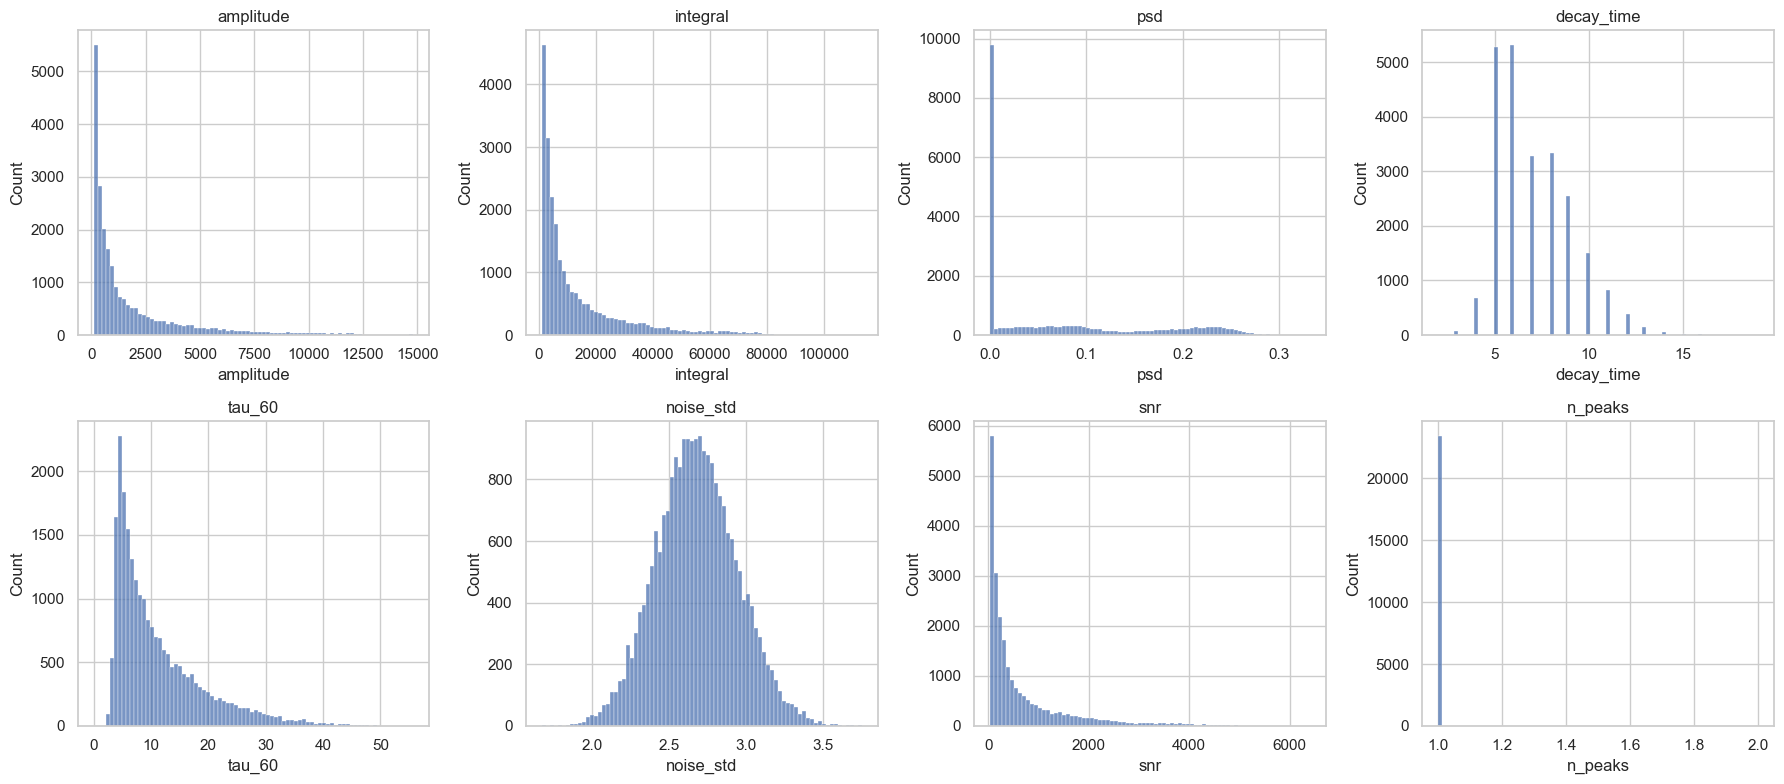

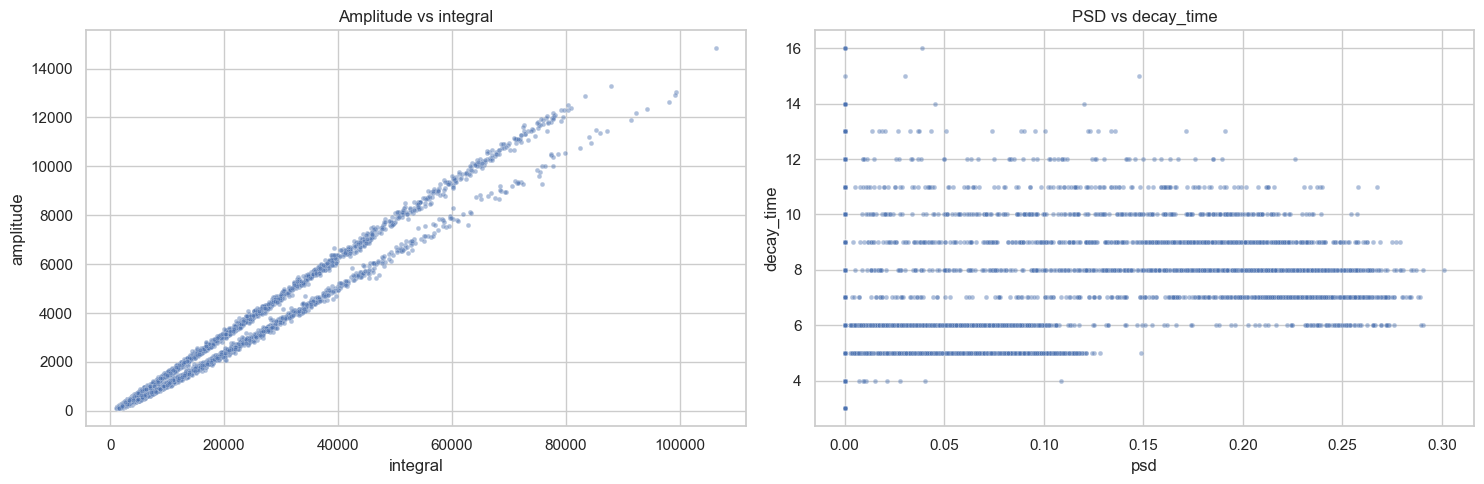

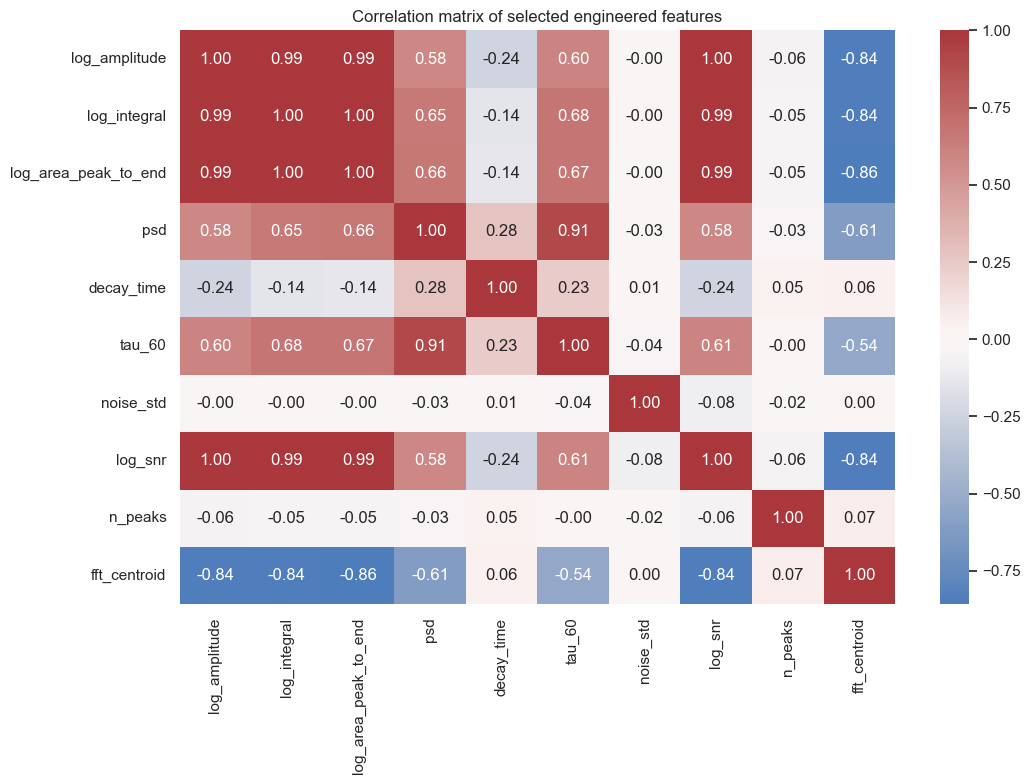

Корреляция amplitude-integral = **0.991**; PSD-decay_time = **0.281**.

In [16]:
# Анализируем распределения ключевых признаков.
key_cols = ["amplitude", "integral", "psd", "decay_time", "tau_60", "noise_std", "snr", "n_peaks"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), key_cols):
    sns.histplot(features[col], bins=80, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Проверяем двумерные проекции физических признаков.
sampled_features = features.sample(6_000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, x, y, title in [
    (axes[0], "integral", "amplitude", "Amplitude vs integral"),
    (axes[1], "psd", "decay_time", "PSD vs decay_time"),
]:
    sns.scatterplot(data=sampled_features, x=x, y=y, s=12, alpha=0.45, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Строим корреляционную матрицу выбранных признаков.
corr_cols = [
    "log_amplitude", "log_integral", "log_area_peak_to_end", "psd", "decay_time",
    "tau_60", "noise_std", "log_snr", "n_peaks", "fft_centroid",
]
corr_matrix = features[corr_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Correlation matrix of selected engineered features")
plt.tight_layout()
plt.show()

# Сохраняем ключевые числовые выводы.
corr_amp_integral = features["amplitude"].corr(features["integral"])
corr_psd_decay = features["psd"].corr(features["decay_time"])
corr_noise_amp = features["noise_std"].corr(features["amplitude"])
strong_corr_count = int(corr_matrix.abs().where(~np.eye(len(corr_cols), dtype=bool)).gt(0.85).sum().sum() / 2)

display(Markdown(
    f"Корреляция amplitude-integral = **{corr_amp_integral:.3f}**; "
    f"PSD-decay_time = **{corr_psd_decay:.3f}**."
))


Видим, что `amplitude`, `integral`, `SNR` и `energy` скошены вправо. 
- `noise_std` почти не связан с амплитудой (`corr = -0.005`).
- `amplitude` и `integral` сильно связаны (`corr = 0.991`), но на scatter видны две ветви, поэтому эта плоскость полезна для разделения.
- `PSD` и `decay_time` связаны слабее (`corr = 0.281`), поэтому decay-признаки лишь дополняют PSD.

## 6. Выбор моделей

Стандартизируем признаки, чтобы разные масштабы не влияли на расстояния:

$$
z = \frac{x - \mu}{\sigma}
$$

Сравниваем несколько подходов:

* **`KMeans`** - делит объекты на `K` кластеров, минимизируя расстояние до центров:

$$
\min \sum_{k=1}^{K}\sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

* **`GaussianMixture`** - описывает данные как смесь нормальных распределений:

$$
p(x) = \sum_{k=1}^{K}\pi_k \mathcal{N}(x | \mu_k, \Sigma_k)
$$

* **`AgglomerativeClustering`** - постепенно объединяет похожие объекты в иерархию.

* **`DBSCAN`** - выделяет плотные области, а шумовые точки можно относить к cluster `2`.

* **`PDF-guided PCA boundary`** - разделяет сигналы в PCA-плоскости амплитудно-интегральных признаков:

$$
Z = XW
$$

Cluster `2` интерпретируется как область около PCA-границы, где сигналы сложнее уверенно отнести к одному из двух основных типов.

In [19]:
# Упорядочиваем кластеры по медианному PSD.
def _cluster_order(
    labels: np.ndarray,
    feature_frame: pd.DataFrame,
    selected_labels: list[int] | None = None,
    order_col: str = "psd",
) -> list[int]:
    medians = feature_frame.groupby(labels)[order_col].median()
    if selected_labels is not None:
        medians = medians.loc[selected_labels]
    return medians.sort_values().index.tolist()


# Нормализуем номера кластеров под формат задачи.
def normalize_labels(
    labels: np.ndarray,
    feature_frame: pd.DataFrame,
    anomaly_label: int | None = None,
    order_col: str = "psd",
) -> np.ndarray:
    labels = np.asarray(labels)
    normalized = np.full(labels.shape[0], 2, dtype=int)
    unique_labels = sorted(set(labels))

    if anomaly_label is not None and anomaly_label in unique_labels:
        normal_labels = [lab for lab in unique_labels if lab != anomaly_label]
        for new_label, old_label in enumerate(_cluster_order(labels, feature_frame, normal_labels, order_col)[:2]):
            normalized[labels == old_label] = new_label
        normalized[labels == anomaly_label] = 2
        return normalized

    for new_label, old_label in enumerate(_cluster_order(labels, feature_frame, order_col=order_col)[:3]):
        normalized[labels == old_label] = new_label
    return normalized


# Преобразуем DBSCAN-шум в cluster 2.
def normalize_dbscan_labels(labels: np.ndarray, feature_frame: pd.DataFrame) -> np.ndarray:
    labels = np.asarray(labels)
    normalized = np.full(labels.shape[0], 2, dtype=int)
    clusters = [label for label in sorted(set(labels)) if label != -1]
    if not clusters:
        return normalized

    main_clusters = pd.Series(labels).value_counts().loc[clusters].head(2).index.tolist()
    for new_label, old_label in enumerate(_cluster_order(labels, feature_frame, main_clusters)):
        normalized[labels == old_label] = new_label
    return normalized


# Строим PCA-границу в плоскости площадь-амплитуда.
def pca_boundary(
    feature_frame: pd.DataFrame,
    area_col: str = "area_peak_to_end",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = feature_frame[[area_col, "amplitude"]].to_numpy()
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(StandardScaler().fit_transform(x))
    return (coords[:, 1] > 0).astype(int), np.abs(coords[:, 1]), coords


# Относим ближайшие к границе объекты к cluster 2.
def labels_with_margin(side: np.ndarray, margin: np.ndarray, q: float) -> np.ndarray:
    labels = side.copy().astype(int)
    labels[margin <= np.quantile(margin, q)] = 2
    return labels


# Считаем внутренние метрики кластеризации.
def evaluate_clustering(
    name: str,
    labels: np.ndarray,
    metric_frame: pd.DataFrame,
    scope: str = "full",
) -> dict:
    labels = np.asarray(labels)
    unique = np.unique(labels)
    result = {
        "method": name,
        "scope": scope,
        "n_clusters": len(unique),
        "class_2_share": float(np.mean(labels == 2)),
        "counts": pd.Series(labels).value_counts().sort_index().to_dict(),
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }
    if len(unique) < 2 or len(unique) >= len(labels):
        return result

    x_scaled = StandardScaler().fit_transform(metric_frame)
    try:
        result.update({
            "silhouette": silhouette_score(x_scaled, labels, sample_size=min(3_000, len(labels)), random_state=RANDOM_STATE),
            "calinski_harabasz": calinski_harabasz_score(x_scaled, labels),
            "davies_bouldin": davies_bouldin_score(x_scaled, labels),
        })
    except ValueError:
        pass
    return result


# Задаем наборы признаков для сравнения моделей.
metric_cols = ["log_area_peak_to_end", "log_amplitude", "psd", "decay_time", "tau_60", "log_snr"]
feature_sets = {
    "core_pdf": ["log_area_peak_to_end", "log_amplitude", "psd", "decay_time"],
    "extended_pdf": metric_cols,
    "shape_noise": ["psd", "decay_time", "tau_60", "rise_time", "fwhm", "log_snr"],
}


Для сравнения классических моделей сформировали набор из 6 признаков, который объединяет размер импульса, форму хвоста и отношение сигнал/шум:
 - `log_area_peak_to_end`
 - `log_amplitude`
 -  `psd`
 -  `decay_time`
 -   `tau_60`
 -   `log_snr`.

Тяжелые методы (`Agglomerative`, `DBSCAN`) считаются на подвыборке **4000** объектов, чтобы notebook запускался стабильно.

## 7. Сравнение моделей

Так как открытой разметки нет, для сравнения моделей используем внутренние метрики, которые показывают компактность и разделимость кластеров.

- **Silhouette** - чем выше, тем лучше разделены кластеры

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

- **Calinski-Harabasz**- чем выше, тем лучше отношение межкластерной и внутрикластерной дисперсии
- **Davies-Bouldin**- чем ниже, тем лучше
- **class_2_share**- доля объектов в неоднозначном кластере.

Отдельно важно сравнить классические модели с физически мотивированным PCA-boundary: он может иметь хуже внутренние метрики, но лучше соответствовать постановке задачи.

In [22]:
# Сравниваем базовые модели кластеризации.
comparison_rows, candidate_labels = [], {}
x_full = StandardScaler().fit_transform(features[feature_sets["extended_pdf"]])


# Добавляем результат модели в общую таблицу.
def add_comparison(name: str, labels: np.ndarray, frame: pd.DataFrame, scope: str = "full") -> None:
    comparison_rows.append(evaluate_clustering(name, labels, frame[metric_cols], scope=scope))


# KMeans и GMM считаются на полном датасете.
kmeans_labels = normalize_labels(
    KMeans(n_clusters=3, n_init=50, random_state=RANDOM_STATE).fit_predict(x_full),
    features,
)
gmm_labels = normalize_labels(
    GaussianMixture(n_components=3, covariance_type="full", n_init=10, random_state=RANDOM_STATE).fit_predict(x_full),
    features,
)
candidate_labels.update({"KMeans extended_pdf": kmeans_labels, "GMM extended_pdf": gmm_labels})
add_comparison("KMeans extended_pdf", kmeans_labels, features)
add_comparison("GMM extended_pdf", gmm_labels, features)

# Тяжелые методы считаются на детерминированной подвыборке.
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = np.sort(rng.choice(N_SIGNALS, size=MODEL_SAMPLE_SIZE, replace=False))
sample_features = features.iloc[sample_idx].reset_index(drop=True)
x_sample = StandardScaler().fit_transform(sample_features[feature_sets["extended_pdf"]])

agg_labels = normalize_labels(
    AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(x_sample),
    sample_features,
)
add_comparison("Agglomerative extended_pdf", agg_labels, sample_features, scope=f"sample_{MODEL_SAMPLE_SIZE}")

x_dbscan = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(x_sample)
dbscan_labels = normalize_dbscan_labels(DBSCAN(eps=0.22, min_samples=25).fit_predict(x_dbscan), sample_features)
add_comparison("DBSCAN PCA2 sample", dbscan_labels, sample_features, scope=f"sample_{MODEL_SAMPLE_SIZE}")

# Добавляем физически мотивированный PCA-boundary baseline.
side, margin, pca_coords = pca_boundary(features, "area_peak_to_end")
pdf_labels = labels_with_margin(side, margin, 0.10)
candidate_labels["PDF PCA boundary margin10"] = pdf_labels
add_comparison("PDF PCA boundary margin10", pdf_labels, features)

comparison_df = pd.DataFrame(comparison_rows).sort_values("silhouette", ascending=False, na_position="last")
display(comparison_df)

best_silhouette = comparison_df.iloc[0]
best_ch = comparison_df.loc[comparison_df["calinski_harabasz"].idxmax()]
best_db = comparison_df.loc[comparison_df["davies_bouldin"].idxmin()]

,method,scope,n_clusters,class_2_share,counts,silhouette,calinski_harabasz,davies_bouldin
0,KMeans extended_pdf,full,3,0.2656,"{0: 11947, 1: 5297, 2: 6235}",0.4385,20830.6842,0.8517
1,GMM extended_pdf,full,3,0.3711,"{0: 9719, 1: 5047, 2: 8713}",0.3633,15356.8922,1.0346
2,Agglomerative extended_pdf,sample_4000,3,0.3683,"{0: 1384, 1: 1143, 2: 1473}",0.3359,2979.3018,1.0902
3,DBSCAN PCA2 sample,sample_4000,3,0.1883,"{0: 2465, 1: 782, 2: 753}",0.2018,714.5520,4.9767
4,PDF PCA boundary margin10,full,3,0.1000,"{0: 8218, 1: 12913, 2: 2348}",0.1167,5926.7518,1.6112


По результатам сравнения в качестве основной модели выбираем **PDF-guided PCA boundary**. Несмотря на то что `KMeans` показывает лучшие внутренние метрики, PCA-boundary лучше согласуется с физическим смыслом задачи и дает проверенный Kaggle score **0.73005**.

## 8. Подбор гиперпараметров

Будем перебирать следующие параметры:

- наборы признаков `core_pdf`, `extended_pdf`, `shape_noise`
- число PCA-компонент `2`, `3`, `5`
- `KMeans n_init`
- `GMM covariance_type`
- `DBSCAN eps/min_samples`
- ширина пограничной области PCA-boundary: `5/10/15/20/25%`

Для PCA-boundary неоднозначная область задается через расстояние до разделяющей границы:

$$
cluster_2 = \{i: |PC2_i| \le q_{margin}(|PC2|)\}
$$

Максимум внутренней метрики не обязан совпадать с максимумом Kaggle score. 

In [25]:
# Перебираем гиперпараметры моделей.
tuning_rows = []

# Добавляем строку в tuning-таблицу.
def add_tuning(family: str, method: str, labels: np.ndarray, frame: pd.DataFrame, scope: str = "full") -> None:
    row = evaluate_clustering(method, labels, frame[metric_cols], scope=scope)
    row["family"] = family
    tuning_rows.append(row)


# Перебор KMeans и GMM по наборам признаков.
for set_name, cols in feature_sets.items():
    x_scaled = StandardScaler().fit_transform(features[cols])

    for n_components in [2, 3, min(5, len(cols))]:
        if n_components > x_scaled.shape[1]:
            continue
        x_pca = PCA(n_components=n_components, random_state=RANDOM_STATE).fit_transform(x_scaled)
        for n_init in [10, 30]:
            labels = KMeans(n_clusters=3, n_init=n_init, random_state=RANDOM_STATE).fit_predict(x_pca)
            add_tuning("KMeans", f"KMeans {set_name} PCA{n_components} n_init{n_init}", normalize_labels(labels, features), features)

    for covariance_type in ["full", "tied", "diag", "spherical"]:
        labels = GaussianMixture(
            n_components=3,
            covariance_type=covariance_type,
            n_init=5,
            random_state=RANDOM_STATE,
        ).fit_predict(x_scaled)
        add_tuning("GMM", f"GMM {set_name} {covariance_type}", normalize_labels(labels, features), features)

# Перебор DBSCAN на подвыборке.
x_sample_scaled = StandardScaler().fit_transform(sample_features[feature_sets["extended_pdf"]])
x_sample_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(x_sample_scaled)
for eps in [0.16, 0.20, 0.24]:
    for min_samples in [15, 30]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(x_sample_pca)
        labels = normalize_dbscan_labels(labels, sample_features)
        add_tuning("DBSCAN", f"DBSCAN eps{eps} min{min_samples}", labels, sample_features, scope=f"sample_{MODEL_SAMPLE_SIZE}")

# Перебор ширины пограничной зоны PCA-boundary.
for margin_q in [0.05, 0.10, 0.15, 0.20, 0.25]:
    labels = labels_with_margin(side, margin, margin_q)
    add_tuning("PDF_PCA_boundary", f"PDF PCA boundary margin{int(margin_q * 100):02d}", labels, features)

tuning_cols = [
    "family", "method", "scope", "n_clusters", "class_2_share",
    "silhouette", "calinski_harabasz", "davies_bouldin", "counts",
]
tuning_df = pd.DataFrame(tuning_rows)[tuning_cols].sort_values("silhouette", ascending=False, na_position="last")
pdf_tuning = tuning_df[tuning_df["family"] == "PDF_PCA_boundary"].copy()

display(tuning_df.head(20))
display(pdf_tuning)

selected_method_name = "PDF PCA boundary margin10"
selected_row = tuning_df[tuning_df["method"] == selected_method_name].iloc[0]
best_internal_row = tuning_df.iloc[0]


,family,method,scope,n_clusters,class_2_share,silhouette,calinski_harabasz,davies_bouldin,counts
15,KMeans,KMeans extended_pdf PCA5 n_init30,full,3,0.2655,0.4385,20830.6797,0.8516,"{0: 11949, 1: 5296, 2: 6234}"
10,KMeans,KMeans extended_pdf PCA2 n_init10,full,3,0.2669,0.4385,20804.7394,0.8527,"{0: 11943, 1: 5269, 2: 6267}"
11,KMeans,KMeans extended_pdf PCA2 n_init30,full,3,0.2669,0.4385,20804.8947,0.8526,"{0: 11944, 1: 5269, 2: 6266}"
14,KMeans,KMeans extended_pdf PCA5 n_init10,full,3,0.2656,0.4384,20830.6525,0.8519,"{0: 11942, 1: 5301, 2: 6236}"
12,KMeans,KMeans extended_pdf PCA3 n_init10,full,3,0.2627,0.4383,20826.6691,0.8489,"{0: 12022, 1: 5290, 2: 6167}"
13,KMeans,KMeans extended_pdf PCA3 n_init30,full,3,0.2627,0.4382,20826.7255,0.8492,"{0: 12016, 1: 5296, 2: 6167}"
19,GMM,GMM extended_pdf spherical,full,3,0.2567,0.4362,20121.9942,0.8196,"{0: 13055, 1: 4396, 2: 6028}"
9,GMM,GMM core_pdf spherical,full,3,0.2451,0.4345,19490.2522,0.8020,"{0: 13639, 1: 4085, 2: 5755}"
2,KMeans,KMeans core_pdf PCA3 n_init10,full,3,0.2921,0.4308,20429.0384,0.8943,"{0: 11038, 1: 5583, 2: 6858}"
3,KMeans,KMeans core_pdf PCA3 n_init30,full,3,0.2921,0.4308,20429.0384,0.8943,"{0: 11038, 1: 5583, 2: 6858}"


,family,method,scope,n_clusters,class_2_share,silhouette,calinski_harabasz,davies_bouldin,counts
40,PDF_PCA_boundary,PDF PCA boundary margin25,full,3,0.2500,0.2069,8504.6720,1.4362,"{0: 7284, 1: 10325, 2: 5870}"
39,PDF_PCA_boundary,PDF PCA boundary margin20,full,3,0.2000,0.1788,7653.7603,1.4941,"{0: 7552, 1: 11231, 2: 4696}"
38,PDF_PCA_boundary,PDF PCA boundary margin15,full,3,0.1500,0.1459,6783.0487,1.5480,"{0: 7869, 1: 12088, 2: 3522}"
37,PDF_PCA_boundary,PDF PCA boundary margin10,full,3,0.1000,0.1167,5926.7518,1.6112,"{0: 8218, 1: 12913, 2: 2348}"
36,PDF_PCA_boundary,PDF PCA boundary margin05,full,3,0.0500,0.0897,5027.9106,1.6844,"{0: 8626, 1: 13679, 2: 1174}"


Лучшее значение Silhouette снова показывает `KMeans extended_pdf PCA5 n_init30`:

$$
Silhouette = 0.4385
$$

Для PCA-boundary увеличение margin с **5%** до **25%** улучшает Silhouette, но сильно расширяет cluster `2`: с **1174** до **5870** сигналов.

Финальным выбран margin **10%**. При нем в cluster `2` попадает **2348** сигналов, а проверенный Kaggle score составляет **0.73005**.

## 9. Финальная модель и интерпретация

По итогам проведенного анализа выбираем финальный метод: **`pdf_pca_boundary_area_peak_to_end_margin10_perm1_012`**

Алгоритм реализации следующий:
1. Берем признаки `area_peak_to_end` и `amplitude`
2. Стандартизируем их
3. Строим PCA на 2 компоненты
4. Разделяем два основных класса по знаку второй компоненты
5. Ближайшие к PCA-границе **10%** объектов относим в cluster `2`
6. Сохраняем выбранный порядок labels `0/1/2` (`perm1_012`) для итогового файла.

,count,median_psd,median_amplitude,median_integral,median_decay,median_noise,share
cluster,,,,,,,
0,8218,0.1923,1409.1699,12655.9971,8.0000,2.6740,0.3500
1,12913,0.0000,638.1396,4603.6602,6.0000,2.6746,0.5500
2,2348,0.0000,270.0400,3006.1460,9.0000,2.6760,0.1000


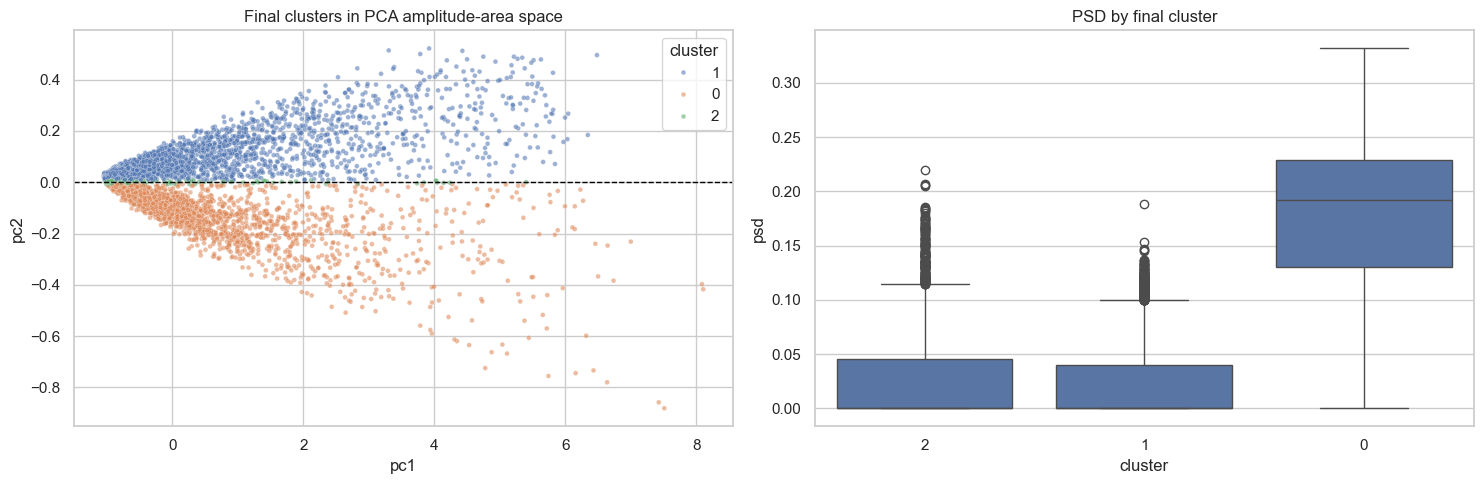

,index,cluster
0,0,2
1,1,1
2,2,1
3,3,0
4,4,1


,count
cluster,
0,8218
1,12913
2,2348


Cluster 2: **2348** сигналов (**10.0%**); median PSD cluster 0 = **0.1923**.

In [41]:
# Считаем финальные метки по PCA-boundary.
FINAL_METHOD = "pdf_pca_boundary_area_peak_to_end_margin10_perm1_012"
FINAL_MARGIN = 0.10
final_side, final_margin, final_pca_coords = pca_boundary(features, "area_peak_to_end")
final_labels = labels_with_margin(final_side, final_margin, FINAL_MARGIN)

# Строим профиль финальных кластеров.
cluster_profile = features.assign(cluster=final_labels).groupby("cluster").agg(
    count=("amplitude", "size"),
    median_psd=("psd", "median"),
    median_amplitude=("amplitude", "median"),
    median_integral=("integral", "median"),
    median_decay=("decay_time", "median"),
    median_noise=("noise_std", "median"),
)
cluster_profile["share"] = cluster_profile["count"] / N_SIGNALS
display(cluster_profile)

# Визуализируем финальные кластеры и PSD.
final_plot_df = pd.DataFrame({
    "pc1": final_pca_coords[:, 0],
    "pc2": final_pca_coords[:, 1],
    "cluster": final_labels.astype(str),
    "psd": features["psd"],
}).sample(8_000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=final_plot_df, x="pc1", y="pc2", hue="cluster", s=12, alpha=0.55, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Final clusters in PCA amplitude-area space")
sns.boxplot(data=pd.DataFrame({"cluster": final_labels.astype(str), "psd": features["psd"]}), x="cluster", y="psd", ax=axes[1])
axes[1].set_title("PSD by final cluster")
plt.tight_layout()
plt.show()

# Формируем итоговый файл 
submission = pd.DataFrame({
    "index": np.arange(N_SIGNALS, dtype=int),
    "cluster": final_labels.astype(int),
})

submission.to_csv("submission.csv", index=False)
submission.to_csv(OUTPUT_DIR / f"{FINAL_METHOD}.csv", index=False)

display(submission.head())
display(submission["cluster"].value_counts().sort_index().rename("count").to_frame())


# Формируем интерпретацию финальных кластеров.
cluster_2_count = int(cluster_profile.loc[2, "count"])
cluster_2_share = cluster_profile.loc[2, "share"]
display(Markdown(
    f"Cluster 2: **{cluster_2_count}** сигналов (**{cluster_2_share:.1%}**); "
    f"median PSD cluster 0 = **{cluster_profile.loc[0, 'median_psd']:.4f}**."
))


**В итоге получаем финальное распределение классов:**
- `0` - **8218** сигналов (**35%**)
- `1` - **12913** (**55%**)
- `2` - **2348** (**10%**).

- На PCA-графике cluster `2` лежит вдоль линии `PC2 = 0`, то есть действительно соответствует пограничной области между двумя основными зонами.

- По boxplot PSD видно, что cluster `0` имеет более выраженный хвост (median PSD = 0.1923), а clusters `1` и `2` ближе к коротким или неоднозначным импульсам (median PSD = 0.0000).

## 10. Итоговые выводы

В этой работе мы перешли от сырых временных рядов к более понятному описанию сигналов:

- Сначала изучили форму импульсов, baseline, шум и положение пиков, а затем выполнили baseline correction, чтобы привести сигналы к удобному для анализа виду.

- Вместо всех 500 отсчетов были построены физически осмысленные признаки: `amplitude`, `integral`, `PSD`, `decay_time`, `tail_integral`, `energy` и другие характеристики формы импульса. Такой набор признаков устойчивее к шуму и лучше отражает различия между типами событий.

- Для кластеризации были сравнены `KMeans`, `GaussianMixture`, `AgglomerativeClustering`, `DBSCAN` и **PDF-guided PCA boundary**. Хотя `KMeans` показал лучшие внутренние метрики, финальным методом выбран **PDF-guided PCA boundary**, потому что он лучше согласуется с физическим смыслом задачи.

- Итоговая модель выделяет два основных типа сигналов, а cluster `2` оставляет для неоднозначных событий около границы между ними. На основе финальных меток был сформирован файл `submission.csv`.

- Проверенный Kaggle score финального решения: **0.73005**.

Скриншот строки с результатом из лидерборда Kaggle: https://disk.yandex.ru/i/w-P-_96ywQlmdw